In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries load ho gayi!")

Libraries load ho gayi!


In [2]:
df = pd.read_csv('../data/IPL.csv', low_memory=False)

print("Shape:", df.shape)
print("Matches:", df['match_id'].nunique())
print("Years:", sorted(df['year'].unique()))

Shape: (283678, 65)
Matches: 1193
Years: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [3]:
# Pehle saare columns dekho
print("Total columns:", len(df.columns))
print("\nSaare columns:")
for i, col in enumerate(df.columns):
    print(f"{i+1:3}. {col}")

Total columns: 65

Saare columns:
  1. Unnamed: 0
  2. match_id
  3. date
  4. match_type
  5. event_name
  6. innings
  7. batting_team
  8. bowling_team
  9. over
 10. ball
 11. ball_no
 12. batter
 13. bat_pos
 14. runs_batter
 15. balls_faced
 16. bowler
 17. valid_ball
 18. runs_extras
 19. runs_total
 20. runs_bowler
 21. runs_not_boundary
 22. extra_type
 23. non_striker
 24. non_striker_pos
 25. wicket_kind
 26. player_out
 27. fielders
 28. runs_target
 29. review_batter
 30. team_reviewed
 31. review_decision
 32. umpire
 33. umpires_call
 34. player_of_match
 35. match_won_by
 36. win_outcome
 37. toss_winner
 38. toss_decision
 39. venue
 40. city
 41. day
 42. month
 43. year
 44. season
 45. gender
 46. team_type
 47. superover_winner
 48. result_type
 49. method
 50. balls_per_over
 51. overs
 52. event_match_no
 53. stage
 54. match_number
 55. team_runs
 56. team_balls
 57. team_wicket
 58. new_batter
 59. power_surge_start
 60. batter_runs
 61. batter_balls
 62. bowle

In [4]:
# Sirf kaam ke columns lo
cols = ['match_id', 'batting_team', 'bowling_team',
        'toss_winner', 'toss_decision', 'venue', 
        'year', 'match_won_by', 'win_outcome']

match_df = df[cols].copy()

# Har match ki pehli row lo — kyunki yeh info har ball pe repeat hoti hai
match_df = match_df.drop_duplicates(subset='match_id')

print("Shape:", match_df.shape)
print("\nSample:")
match_df.head()

Shape: (1193, 9)

Sample:


,match_id,batting_team,bowling_team,toss_winner,toss_decision,venue,year,match_won_by,win_outcome
0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,2008,Kolkata Knight Riders,140 runs
225,335983,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",2008,Chennai Super Kings,33 runs
473,335984,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,Feroz Shah Kotla,2008,Delhi Daredevils,9 wickets
692,335985,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,2008,Royal Challengers Bangalore,5 wickets
938,335986,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,Eden Gardens,2008,Kolkata Knight Riders,5 wickets


In [5]:
# Missing values dekho
print("Missing values:")
print(match_df.isnull().sum())

Missing values:
match_id          0
batting_team      0
bowling_team      0
toss_winner       0
toss_decision     0
venue             0
year              0
match_won_by      0
win_outcome      24
dtype: int64


In [6]:
print("win_outcome unique values:")
print(match_df['win_outcome'].value_counts())

win_outcome unique values:
win_outcome
6 wickets    133
7 wickets    124
5 wickets    105
8 wickets     88
4 wickets     62
            ... 
112 runs       1
106 runs       1
100 runs       1
83 runs        1
110 runs       1
Name: count, Length: 111, dtype: int64


In [7]:
# win_outcome missing wali rows dekho
print("Missing win_outcome wale matches:")
print(match_df[match_df['win_outcome'].isnull()][['match_id','batting_team','bowling_team','match_won_by','win_outcome']])

Missing win_outcome wale matches:
        match_id                 batting_team                 bowling_team  \
15161     392190             Rajasthan Royals        Kolkata Knight Riders   
30707     419121              Kings XI Punjab          Chennai Super Kings   
57068     501265             Delhi Daredevils                Pune Warriors   
77794     598004  Royal Challengers Bangalore          Sunrisers Hyderabad   
81200     598017             Delhi Daredevils  Royal Challengers Bangalore   
98800     729315             Rajasthan Royals        Kolkata Knight Riders   
113004    829741             Rajasthan Royals              Kings XI Punjab   
115353    829763  Royal Challengers Bangalore             Rajasthan Royals   
121177    829813             Delhi Daredevils  Royal Challengers Bangalore   
144440   1082625                Gujarat Lions               Mumbai Indians   
166931   1175365        Kolkata Knight Riders               Delhi Capitals   
176392   1178424  Royal Challe

In [8]:
# No result matches hatao
match_df = match_df[match_df['win_outcome'].notna()]

# "Unknown" winner wale bhi hatao
match_df = match_df[match_df['match_won_by'] != 'Unknown']

print("Shape after cleaning:", match_df.shape)
print("\nKoi Unknown bacha?", (match_df['match_won_by'] == 'Unknown').sum())

Shape after cleaning: (1169, 9)

Koi Unknown bacha? 0


In [9]:
# Spelling inconsistencies fix karo
fix_teams = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

# Teeno team columns mein fix karo
for col in ['batting_team', 'bowling_team', 'toss_winner', 'match_won_by']:
    match_df[col] = match_df[col].replace(fix_teams)

print("Unique teams after fix:")
print(sorted(match_df['batting_team'].unique()))
print("\nTotal unique teams:", match_df['batting_team'].nunique())

Unique teams after fix:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Total unique teams: 15


In [10]:
# Columns rename karo — readable banao
match_df = match_df.rename(columns={
    'batting_team': 'team1',
    'bowling_team': 'team2'
})

# Target variable banao — team1 jeeti ya nahi
# Agar match_won_by == team1 toh 1, warna 0
match_df['team1_win'] = (match_df['match_won_by'] == match_df['team1']).astype(int)

print("Target variable distribution:")
print(match_df['team1_win'].value_counts())
print("\nSample:")
match_df[['team1', 'team2', 'match_won_by', 'team1_win']].head(8)

Target variable distribution:
team1_win
0    635
1    534
Name: count, dtype: int64

Sample:


,team1,team2,match_won_by,team1_win
0,Kolkata Knight Riders,Royal Challengers Bengaluru,Kolkata Knight Riders,1
225,Chennai Super Kings,Punjab Kings,Chennai Super Kings,1
473,Rajasthan Royals,Delhi Capitals,Delhi Capitals,0
692,Mumbai Indians,Royal Challengers Bengaluru,Royal Challengers Bengaluru,0
938,Deccan Chargers,Kolkata Knight Riders,Kolkata Knight Riders,0
1178,Punjab Kings,Rajasthan Royals,Rajasthan Royals,0
1419,Deccan Chargers,Delhi Capitals,Delhi Capitals,0
1624,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,1


C:\Users\HP\AppData\Local\Temp\ipykernel_14960\2686617585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_counts.index, y=win_counts.values, palette='Blues_d')


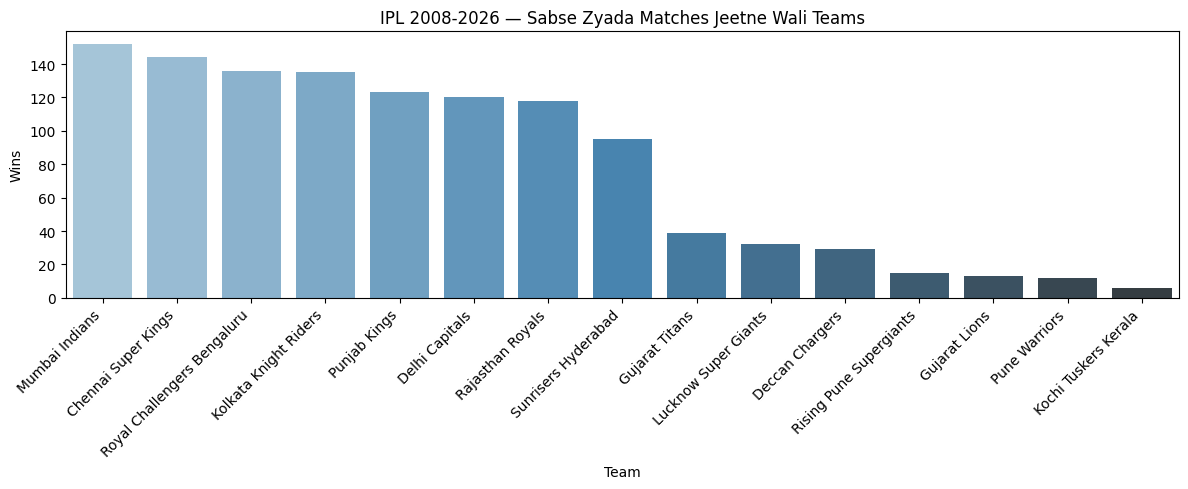

match_won_by
Mumbai Indians                 152
Chennai Super Kings            144
Royal Challengers Bengaluru    136
Kolkata Knight Riders          135
Punjab Kings                   123
Delhi Capitals                 120
Rajasthan Royals               118
Sunrisers Hyderabad             95
Gujarat Titans                  39
Lucknow Super Giants            32
Deccan Chargers                 29
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


In [11]:
# Top winning teams
plt.figure(figsize=(12,5))
win_counts = match_df['match_won_by'].value_counts()
sns.barplot(x=win_counts.index, y=win_counts.values, palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title('IPL 2008-2026 — Sabse Zyada Matches Jeetne Wali Teams')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.tight_layout()
plt.show()

print(win_counts)

Total matches: 1169
Toss jeeta aur match bhi jeeta: 606
Percentage: 51.84%


C:\Users\HP\AppData\Local\Temp\ipykernel_14960\1254261235.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Result', y='Count', data=toss_impact, palette='Blues_d')


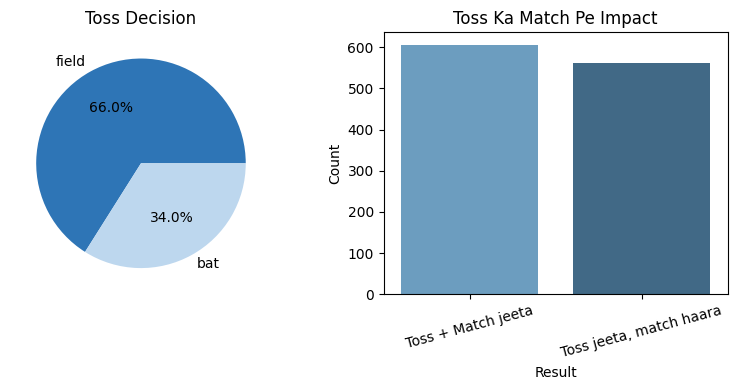

In [12]:
# Toss ka impact
toss_win = match_df[match_df['toss_winner'] == match_df['match_won_by']].shape[0]
total = len(match_df)

print(f"Total matches: {total}")
print(f"Toss jeeta aur match bhi jeeta: {toss_win}")
print(f"Percentage: {round(toss_win/total*100, 2)}%")

# Toss decision distribution
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
match_df['toss_decision'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2E75B6','#BDD7EE'],
    title='Toss Decision'
)

plt.subplot(1,2,2)
toss_impact = pd.DataFrame({
    'Result': ['Toss + Match jeeta', 'Toss jeeta, match haara'],
    'Count': [toss_win, total - toss_win]
})
sns.barplot(x='Result', y='Count', data=toss_impact, palette='Blues_d')
plt.title('Toss Ka Match Pe Impact')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14960\3537011052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_counts.index, y=year_counts.values, palette='Oranges_d')


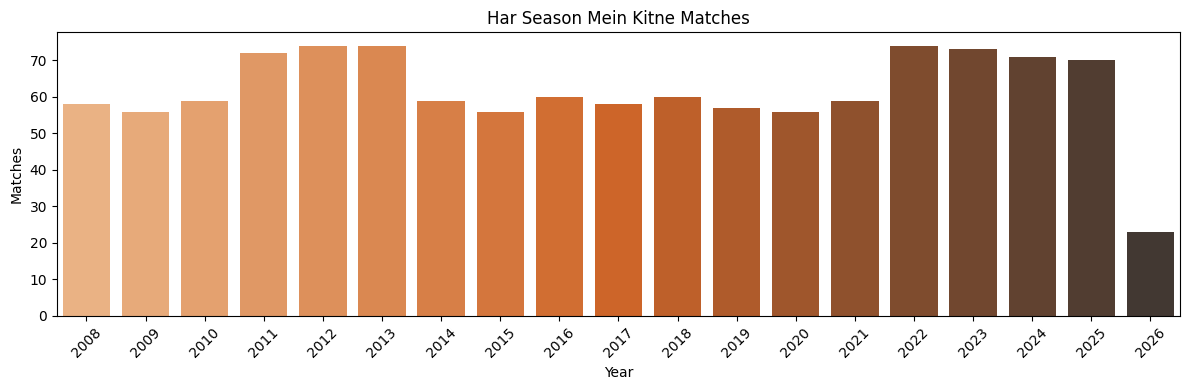

year
2008    58
2009    56
2010    59
2011    72
2012    74
2013    74
2014    59
2015    56
2016    60
2017    58
2018    60
2019    57
2020    56
2021    59
2022    74
2023    73
2024    71
2025    70
2026    23
Name: count, dtype: int64


In [13]:
# Year wise matches aur wins
plt.figure(figsize=(12,4))
year_counts = match_df['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, palette='Oranges_d')
plt.title('Har Season Mein Kitne Matches')
plt.xlabel('Year')
plt.ylabel('Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(year_counts)

In [14]:
print("=" * 50)
print("EDA SUMMARY — IPL Dataset (2008-2026)")
print("=" * 50)
print(f"Total Matches       : {len(match_df)}")
print(f"Seasons             : 2008 to 2026 (19 seasons)")
print(f"Unique Teams        : {match_df['team1'].nunique()}")
print(f"Total Venues        : {match_df['venue'].nunique()}")
print()
print("KEY FINDINGS:")
print("1. Mumbai Indians sabse successful — 152 wins")
print("2. Toss ka match pe weak impact — ~52% correlation")
print("3. 66% teams toss jeet ke field choose karti hain")
print("4. 2026 season incomplete — 23 matches abhi tak")
print("5. Spelling inconsistencies fix ki — 4 teams rename")
print("6. 24 no-result/abandoned matches remove kiye")
print("7. Target variable: team1_win (1=jeeti, 0=haari)")
print("=" * 50)
print("NEXT: 02_preprocessing.ipynb")

EDA SUMMARY — IPL Dataset (2008-2026)
Total Matches       : 1169
Seasons             : 2008 to 2026 (19 seasons)
Unique Teams        : 15
Total Venues        : 59

KEY FINDINGS:
1. Mumbai Indians sabse successful — 152 wins
2. Toss ka match pe weak impact — ~52% correlation
3. 66% teams toss jeet ke field choose karti hain
4. 2026 season incomplete — 23 matches abhi tak
5. Spelling inconsistencies fix ki — 4 teams rename
6. 24 no-result/abandoned matches remove kiye
7. Target variable: team1_win (1=jeeti, 0=haari)
NEXT: 02_preprocessing.ipynb
